# Análisis de Tendencias en GitHub

En este notebook exploraremos datos de repositorios populares de GitHub utilizando su API pública.

**Objetivos:**
- Obtener datos de repositorios con más estrellas.
- Analizar la distribución de lenguajes de programación.
- Identificar patrones entre estrellas, forks y otros atributos.
- Visualizar la evolución temporal de la actividad en GitHub.

**API utilizada:** GitHub REST API (pública, sin autenticación).

In [18]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import time
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


In [19]:
# Configuración de la API de GitHub
BASE_URL = "https://api.github.com"
SEARCH_URL = f"{BASE_URL}/search/repositories"

# Parámetros de búsqueda
QUERY = "stars:>10000"  # Repositorios con más de 10,000 estrellas
SORT = "stars"          # Ordenar por estrellas
ORDER = "desc"          # Descendente
PER_PAGE = 100          # Máximo permitido por página
MAX_PAGES = 5           # Para obtener 500 repositorios (no sobrecargar la API)

# Headers para evitar errores de rate limiting
HEADERS = {
    "Accept": "application/vnd.github.v3+json"
    # Si tienes token, puedes agregar: "Authorization": "token TU_TOKEN"
}

print("✅ Configuración de API lista.")

✅ Configuración de API lista.


In [20]:
def fetch_repositories(query, sort, order, per_page, max_pages, headers):
    """
    Función para obtener repositorios de la API de GitHub.
    Retorna una lista de diccionarios con los datos relevantes.
    """
    repos = []
    for page in range(1, max_pages + 1):
        params = {
            "q": query,
            "sort": sort,
            "order": order,
            "per_page": per_page,
            "page": page
        }
        response = requests.get(SEARCH_URL, params=params, headers=headers)
        
        if response.status_code == 200:
            data = response.json()
            items = data.get("items", [])
            if not items:
                break
            repos.extend(items)
            print(f"✅ Página {page} obtenida: {len(items)} repositorios.")
        else:
            print(f"❌ Error en la página {page}: {response.status_code} - {response.text}")
            break
        
        # Pequeña pausa para no exceder el límite de requests
        time.sleep(1)
    
    print(f"✅ Total de repositorios obtenidos: {len(repos)}")
    return repos

In [21]:
# Obtener repositorios
repos_data = fetch_repositories(QUERY, SORT, ORDER, PER_PAGE, MAX_PAGES, HEADERS)

✅ Página 1 obtenida: 100 repositorios.
✅ Página 2 obtenida: 100 repositorios.
✅ Página 3 obtenida: 100 repositorios.
✅ Página 4 obtenida: 100 repositorios.
✅ Página 5 obtenida: 100 repositorios.
✅ Total de repositorios obtenidos: 500


In [22]:
# Extraer atributos relevantes
repos_list = []
for repo in repos_data:
    repos_list.append({
        "name": repo.get("name"),
        "full_name": repo.get("full_name"),
        "description": repo.get("description"),
        "language": repo.get("language"),
        "stargazers_count": repo.get("stargazers_count"),
        "watchers_count": repo.get("watchers_count"),
        "forks_count": repo.get("forks_count"),
        "open_issues_count": repo.get("open_issues_count"),
        "created_at": repo.get("created_at"),
        "updated_at": repo.get("updated_at"),
        "pushed_at": repo.get("pushed_at"),
        "html_url": repo.get("html_url")
    })

df = pd.DataFrame(repos_list)

# Convertir fechas a datetime
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])
df['pushed_at'] = pd.to_datetime(df['pushed_at'])

# Crear columna de edad (días desde creación)
# Convertir columnas de fecha a datetime con zona horaria UTC
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['updated_at'] = pd.to_datetime(df['updated_at'], utc=True)
df['pushed_at'] = pd.to_datetime(df['pushed_at'], utc=True)

# Crear columna de edad del repositorio (días desde su creación)
now = pd.Timestamp.now(tz='UTC')
df['age_days'] = (now - df['created_at']).dt.days

# Mostrar las primeras filas para verificar
df[['created_at', 'updated_at', 'pushed_at', 'age_days']].head()

# Mostrar información básica
print(f"✅ DataFrame creado con {len(df)} repositorios.")
df.head()

✅ DataFrame creado con 500 repositorios.


,name,full_name,description,language,stargazers_count,watchers_count,forks_count,open_issues_count,created_at,updated_at,pushed_at,html_url,age_days
0,build-your-own-x,codecrafters-io/build-your-own-x,Master programming by recreating your favorite...,Markdown,532733,532733,50387,620,2018-05-09 12:03:18+00:00,2026-07-29 19:22:54+00:00,2026-07-14 19:25:58+00:00,https://github.com/codecrafters-io/build-your-...,3003
1,awesome,sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,NaN,490367,490367,36115,98,2014-07-11 13:42:37+00:00,2026-07-29 19:24:57+00:00,2026-06-30 18:21:16+00:00,https://github.com/sindresorhus/awesome,4401
2,public-apis,public-apis/public-apis,A collective list of free APIs,Python,453312,453312,49918,1611,2016-03-20 23:49:42+00:00,2026-07-29 19:26:45+00:00,2026-07-25 21:34:33+00:00,https://github.com/public-apis/public-apis,3782
3,freeCodeCamp,freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,453120,453120,45729,222,2014-12-24 17:49:19+00:00,2026-07-29 18:50:58+00:00,2026-07-29 17:17:26+00:00,https://github.com/freeCodeCamp/freeCodeCamp,4235
4,free-programming-books,EbookFoundation/free-programming-books,:books: Freely available programming books,Python,393271,393271,66581,78,2013-10-11 06:50:37+00:00,2026-07-29 19:16:42+00:00,2026-07-27 22:15:56+00:00,https://github.com/EbookFoundation/free-progra...,4674


In [23]:
# Guardar datos para no tener que consultar la API cada vez
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/github_repos.csv', index=False)
print("✅ Datos guardados en 'data/github_repos.csv'")

✅ Datos guardados en 'data/github_repos.csv'


# Análisis Exploratorio de Datos (EDA)

Ahora exploraremos los datos obtenidos para identificar tendencias y patrones.

In [24]:
# Estadísticas generales
df.describe()

,stargazers_count,watchers_count,forks_count,open_issues_count,age_days
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,91574.578000,91574.578000,14440.456000,1143.264000,2813.034000
std,62904.966852,62904.966852,14729.585341,2990.637933,1722.889956
min,47907.000000,47907.000000,169.000000,0.000000,47.000000
25%,57660.750000,57660.750000,5860.250000,67.750000,1219.500000
50%,71626.000000,71626.000000,9726.000000,309.000000,2985.000000
75%,96600.500000,96600.500000,16341.500000,882.500000,4214.000000
max,532733.000000,532733.000000,109420.000000,33238.000000,6683.000000


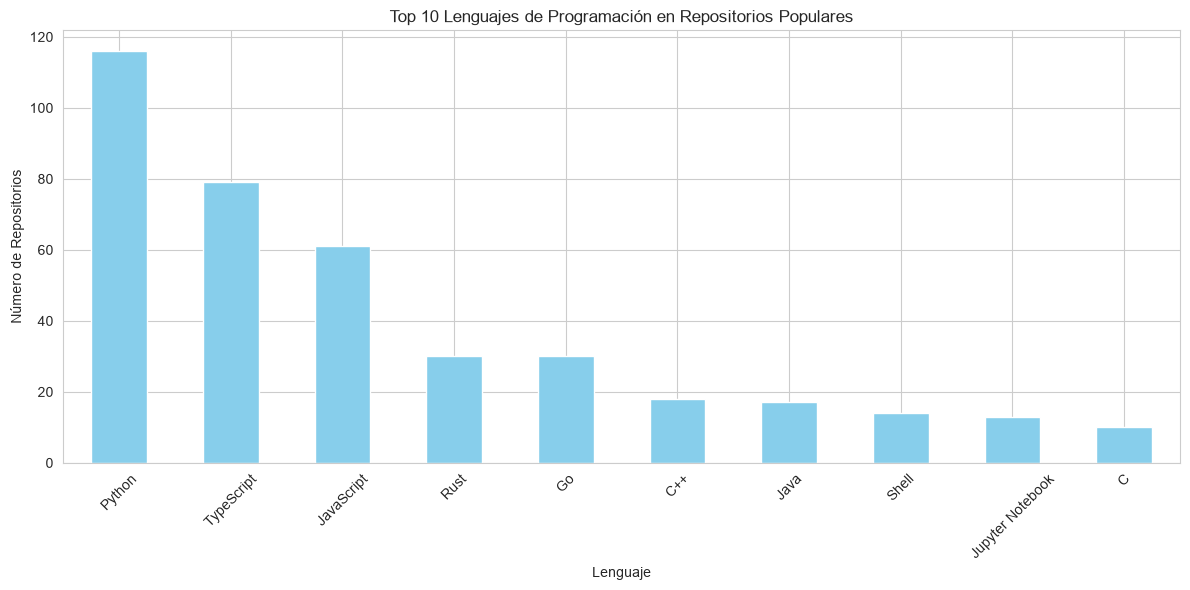

In [25]:
# Top 10 lenguajes más populares
languages = df['language'].value_counts().head(10)

plt.figure(figsize=(12, 6))
languages.plot(kind='bar', color='skyblue')
plt.title('Top 10 Lenguajes de Programación en Repositorios Populares')
plt.xlabel('Lenguaje')
plt.ylabel('Número de Repositorios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

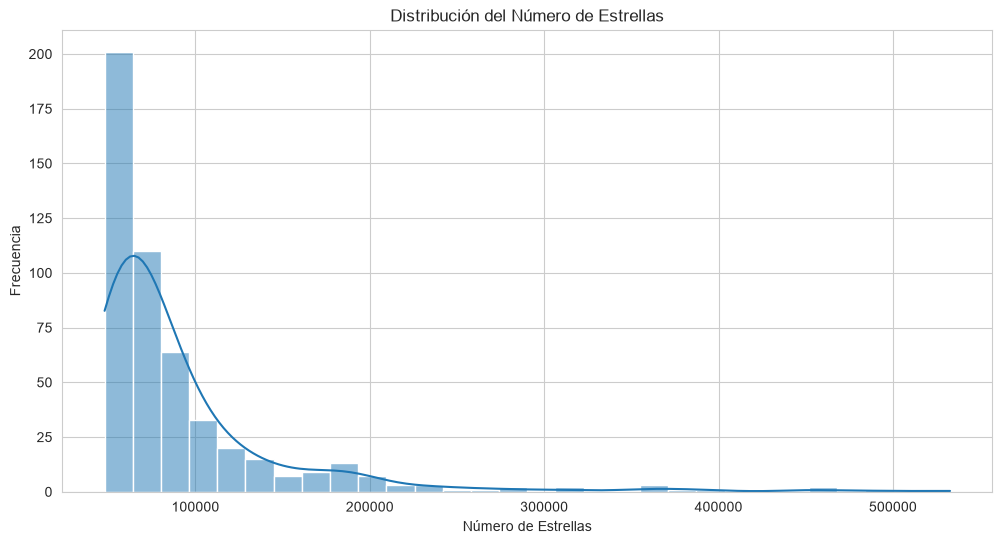

In [26]:
# Histograma de estrellas
plt.figure(figsize=(12, 6))
sns.histplot(df['stargazers_count'], bins=30, kde=True)
plt.title('Distribución del Número de Estrellas')
plt.xlabel('Número de Estrellas')
plt.ylabel('Frecuencia')
plt.show()

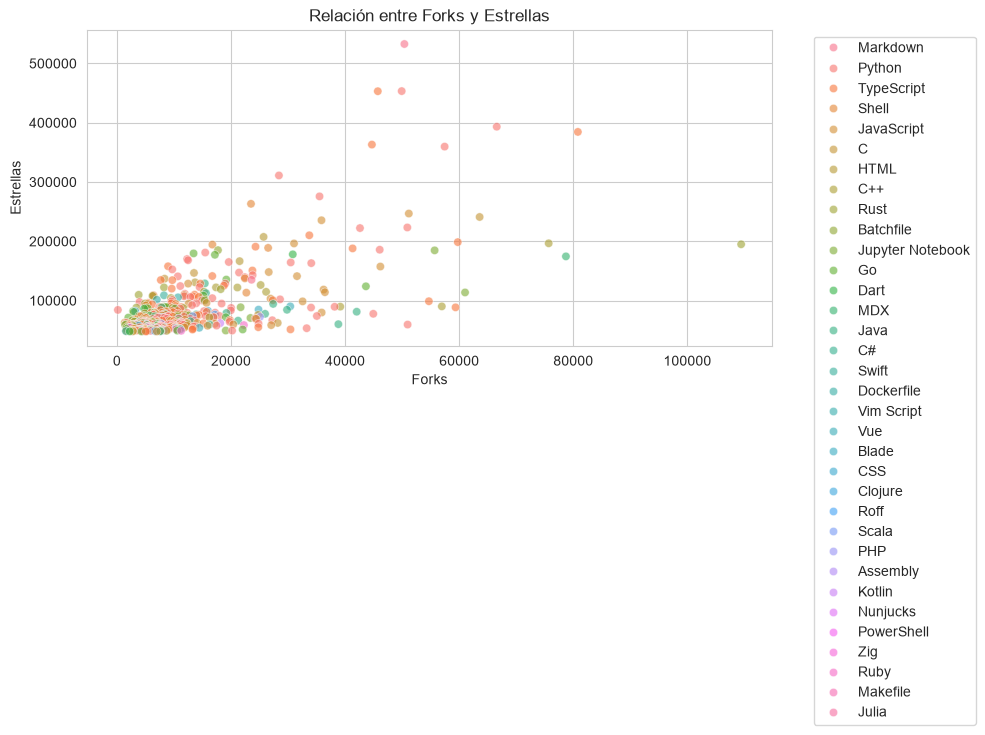

In [27]:
# Scatter plot: estrellas vs forks
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='forks_count', y='stargazers_count', alpha=0.6, hue='language')
plt.title('Relación entre Forks y Estrellas')
plt.xlabel('Forks')
plt.ylabel('Estrellas')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

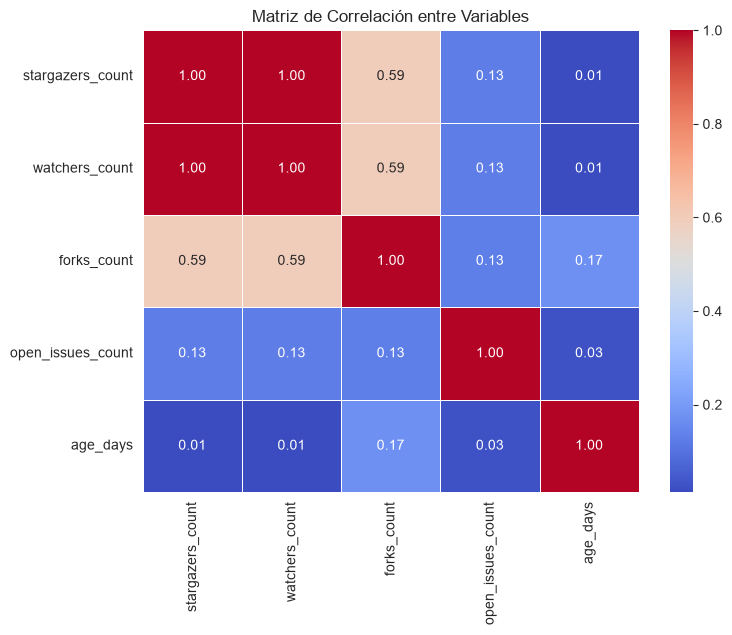

In [28]:
# Matriz de correlación
cols = ['stargazers_count', 'watchers_count', 'forks_count', 'open_issues_count', 'age_days']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación entre Variables')
plt.show()

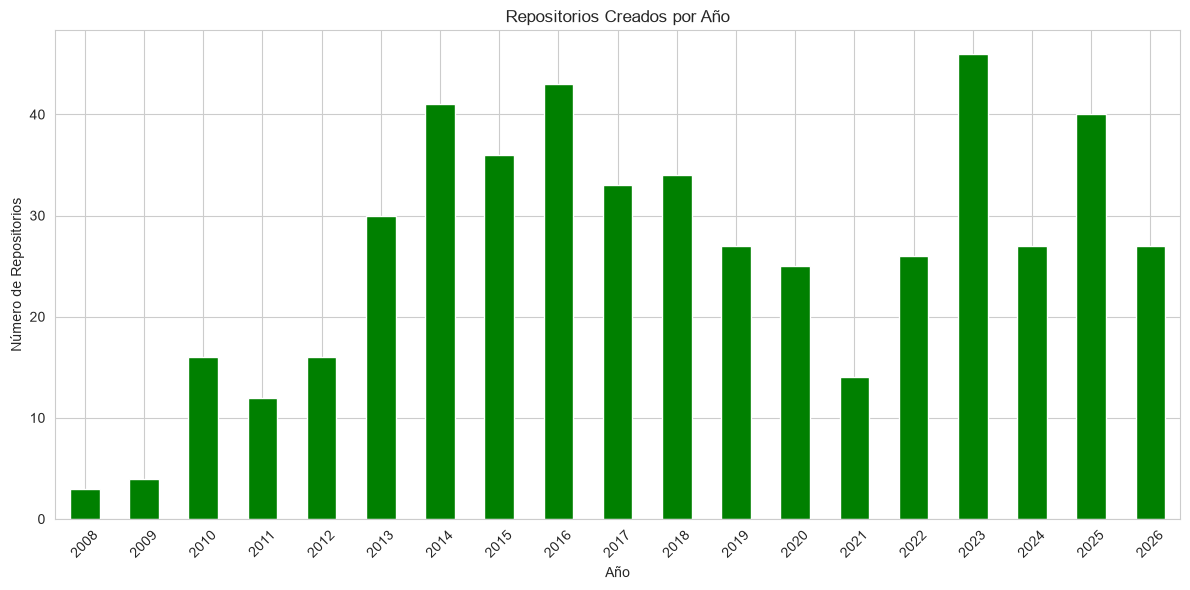

In [29]:
# Número de repositorios creados por año
df['year_created'] = df['created_at'].dt.year
year_counts = df['year_created'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
year_counts.plot(kind='bar', color='green')
plt.title('Repositorios Creados por Año')
plt.xlabel('Año')
plt.ylabel('Número de Repositorios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Top 10 repositorios con más estrellas
top_stars = df.nlargest(10, 'stargazers_count')[['name', 'full_name', 'language', 'stargazers_count']]
top_stars

,name,full_name,language,stargazers_count
0,build-your-own-x,codecrafters-io/build-your-own-x,Markdown,532733
1,awesome,sindresorhus/awesome,NaN,490367
2,public-apis,public-apis/public-apis,Python,453312
3,freeCodeCamp,freeCodeCamp/freeCodeCamp,TypeScript,453120
4,free-programming-books,EbookFoundation/free-programming-books,Python,393271
5,openclaw,openclaw/openclaw,TypeScript,384477
6,developer-roadmap,nilbuild/developer-roadmap,TypeScript,363069
7,system-design-primer,donnemartin/system-design-primer,Python,359669
8,coding-interview-university,jwasham/coding-interview-university,NaN,357429
9,awesome-python,vinta/awesome-python,Python,311039


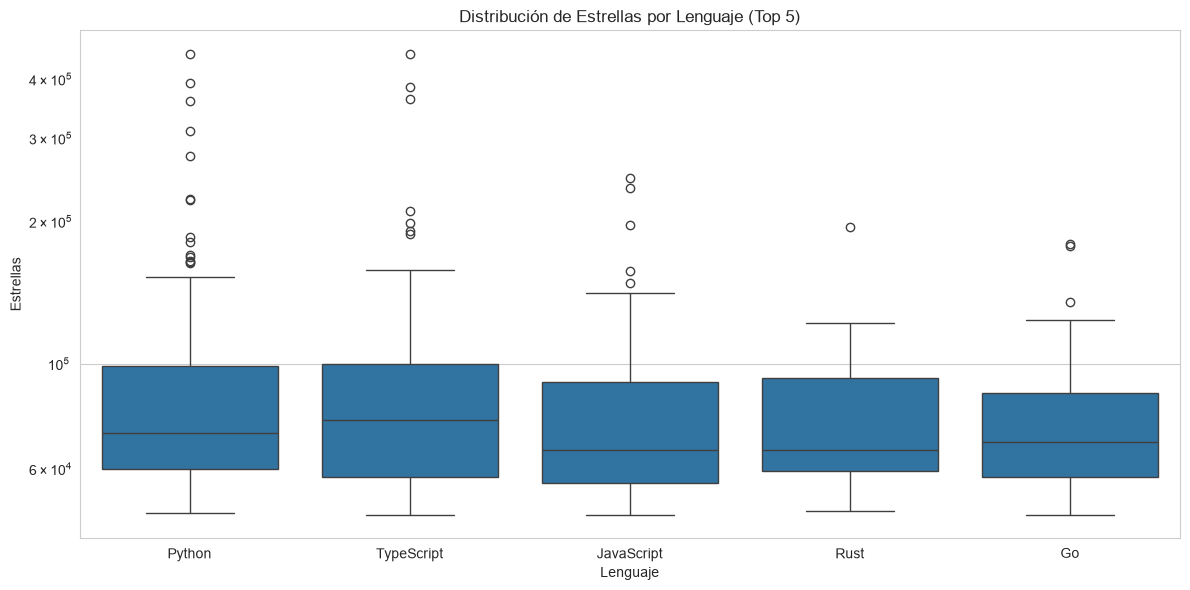

In [31]:
# Boxplot: estrellas por lenguaje (top 5 lenguajes)
top_languages = df['language'].value_counts().head(5).index
df_top_lang = df[df['language'].isin(top_languages)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_lang, x='language', y='stargazers_count')
plt.title('Distribución de Estrellas por Lenguaje (Top 5)')
plt.xlabel('Lenguaje')
plt.ylabel('Estrellas')
plt.yscale('log')  # Escala logarítmica para mejor visualización
plt.tight_layout()
plt.show()

# Conclusiones del Análisis Exploratorio

- **Lenguajes predominantes:** JavaScript, Python, Java y Go son los más comunes entre los repositorios populares.
- **Estrellas:** La mayoría de los repositorios tienen entre 10,000 y 20,000 estrellas, pero algunos superan las 100,000 (ej. freeCodeCamp, Vue.js).
- **Relación estrellas-forks:** Existe una fuerte correlación positiva (≈0.8), lo que indica que los repositorios con muchas estrellas también tienden a ser bifurcados.
- **Tendencia temporal:** La creación de repositorios populares ha aumentado significativamente desde 2015, con un pico en los últimos años.
- **Observación:** Los repositorios en lenguajes como JavaScript y Python muestran mayor variabilidad en el número de estrellas.

**Próximo paso:** En el siguiente notebook, profundizaremos en el análisis temporal y exploraremos posibles factores que impulsan la popularidad.